# Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install system-level dependencies
!apt-get update
!apt-get install -y build-essential cmake ninja-build
!pip install PyWavelets
# Install Python dependencies via pip
!pip install torch==2.2.0 torchvision torchaudio
!pip install pre-commit==3.6.0 ipykernel==6.29.0 dacite==1.8.1 omegaconf==2.3.0
!pip install torchmetrics==1.3.0 tqdm==4.66.1 pytest==8.0.0 pytest-xdist==3.5.0

# clear_output()

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,226 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,630 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 5.9 MB/s eta 0:00:00
Reason for being yanked: <none given>
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 840.2/840.2 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 334.0/334.0 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.67.1
    Uninstalling tqdm-4.67.1:
      Successfully uninstalled tqdm-4.67.1
  Attempting uninstall: pytest
    Found existing installation: pytest 8.3.4
    Uninstalling pytest-8.3.4:
      Successfully uninstalled pytest-8.3.4


# Preprocessing

In [ ]:
! pip install xlstm
from IPython.display import clear_output
clear_output()

import os
os.chdir('/content/drive/MyDrive/xLSTM_v2/xlstm')
!pip install -e .
clear_output()

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/xLSTM/xlstm-ts/data/datasets/BTCUSD_2023_2024.csv', index_col = 'Gmt time')
df.index = pd.to_datetime(df.index, format='%d.%m.%Y %H:%M:%S.%f', errors='coerce')
df = df.rename(columns={'Gmt time':'time', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close':'close', 'Volume':'volume'})

In [ ]:
working_dir = os.getcwd()
FOLDE_NAME = os.path.basename(working_dir)
FILE_NAME = 'fan_v2'

STOCK = 'BTC'
FREQ = '1h'

TRADE_PRICE = 'close'


SEQ_LENGTH = 120
BATCH_SIZE = 16
K = 1

TRAIN_SPLIT = 0.6
VAL_SPLIT = 0.1
TEST_SPLIT = 1 - (TRAIN_SPLIT+VAL_SPLIT)

In [ ]:
path = f'./{FILE_NAME}'

try:
    os.mkdir(path)
    print(f"Directory '{path}' created successfully.")
except FileExistsError:
    print(f"Directory '{path}' already exists.")
except Exception as e:
    print(f"An error occurred: {e}")

del path

Directory './fan_v2' already exists.


In [ ]:
import numpy as np
from preprocessing.utils import CreateTimeFrames
df = CreateTimeFrames(df, [FREQ])[FREQ]
df = df.iloc[-4050:,:]

close = df[f'{TRADE_PRICE}'].to_numpy(dtype=np.int32)
print(f'There are {close.size} {TRADE_PRICE} prices.')

There are 4050 close prices.


In [ ]:
!pip install PyWavelets
clear_output()

[]

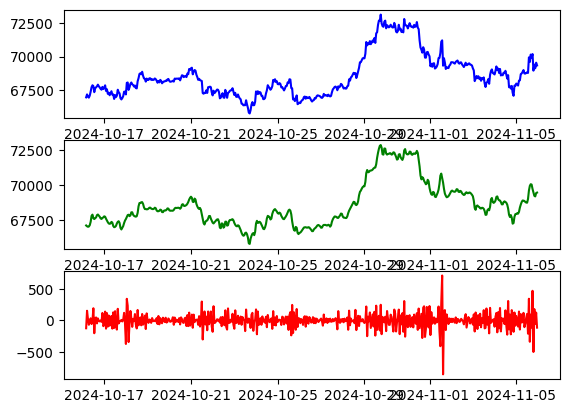

In [ ]:
from preprocessing.denoising import wavelet_denoising

df[f'smoothed_data_{TRADE_PRICE}'] = wavelet_denoising(df[f'{TRADE_PRICE}'])
df['noise'] = df[f'{TRADE_PRICE}'] - df[f'smoothed_data_{TRADE_PRICE}']

import matplotlib.pyplot as plt
# fig = plt.figure(figsize=(8,6))
fig, axs = plt.subplots(3)

axs[0].plot(df[f'{TRADE_PRICE}'].iloc[-500:], color = 'blue')
axs[1].plot(df[f'smoothed_data_{TRADE_PRICE}'].iloc[-500:], color = 'green')
axs[2].plot(df['noise'].iloc[-500:], color = 'red')
plt.plot()

In [ ]:
train = close[:int(np.floor(TRAIN_SPLIT*len(close)))]
val = close[int(np.ceil(TRAIN_SPLIT*len(close))): int(np.floor( (TRAIN_SPLIT+VAL_SPLIT)*len(close) ))]
test = close[int(np.ceil((TRAIN_SPLIT+VAL_SPLIT)*len(close))):]
assert len(train) + len(val) + len(test) == len(df), f"The dimension of price is dividable to SPLIT numbers. Splited len is:{len(train)+len(val)+len(test)} but df len is:{len(df)} "
print(f'train size:{train.size}, val size:{val.size}, test size:{test.size}.')


train size:2430, val size:405, test size:1215.


In [ ]:
close_denoised = df[f'smoothed_data_{TRADE_PRICE}']

In [ ]:
train_denoised = close_denoised[:int(np.floor(TRAIN_SPLIT*len(close_denoised)))]
val_denoised = close_denoised[int(np.ceil(TRAIN_SPLIT*len(close_denoised))): int(np.floor( (TRAIN_SPLIT+VAL_SPLIT)*len(close_denoised) ))]
test_denoised = close_denoised[int(np.ceil((TRAIN_SPLIT+VAL_SPLIT)*len(close_denoised))):]
assert len(train_denoised) + len(val_denoised) + len(test_denoised) == len(df), f"The dimension of price is dividable to SPLIT numbers. Splited len is:{len(train)+len(val)+len(test)} but df len is:{len(df)} "
print(f'train size:{train_denoised.size}, val size:{val_denoised.size}, test size:{test_denoised.size}.')


train size:2430, val size:405, test size:1215.


## Create Sequences

In [ ]:
import torch
def create_sequence(data, seq_length=SEQ_LENGTH):

    num_seq = len(data) - seq_length

    xs = np.zeros((num_seq,seq_length), dtype=np.int32)
    ys = np.zeros(num_seq, dtype=np.int32)

    for i in range(0,num_seq):
        xs[i,:] = data[i:seq_length+i]
        ys[i] = data[i+seq_length]

    xs = torch.from_numpy(xs).unsqueeze(2)
    ys = torch.from_numpy(ys).unsqueeze(1)

    return xs, ys

xs_train, ys_train = create_sequence(train)
xs_val, ys_val = create_sequence(val)
xs_test, ys_test = create_sequence(test)

xs_train_denoised, ys_train_denoised = create_sequence(train_denoised)
xs_val_denoised, ys_val_denoised = create_sequence(val_denoised)
xs_test_denoised, ys_test_denoised = create_sequence(test_denoised)

/tmp/ipykernel_3684/1772114917.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ys[i] = data[i+seq_length]


In [ ]:
def create_dataloader(x, y, batch_size = BATCH_SIZE, shuffle=False):
  dataset = torch.utils.data.TensorDataset(x, y)
  dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
  return dataloader

In [ ]:
train_dataloader = create_dataloader(xs_train, ys_train)
val_dataloader = create_dataloader(xs_val, ys_val)
test_dataloader = create_dataloader(xs_test, ys_test)

train_denoised_dataloader = create_dataloader(xs_train_denoised, ys_train_denoised)
val_denoised_dataloader = create_dataloader(xs_val_denoised, ys_val_denoised)
test_denoised_dataloader = create_dataloader(xs_test_denoised, xs_test_denoised)

# Models
## FAN models

main_freq_part function convert each data into residual and non stationary part by getting data and k.

In [ ]:
def main_freq_part(x, k):
    freq_domain = torch.fft.rfft(x, dim=1)
    magnitudes = torch.abs(freq_domain)
    topk_indices = torch.topk(magnitudes, k , dim=1, largest=True).indices

    mask = torch.ones_like(freq_domain, dtype=torch.complex64)
    for b in range(x.shape[0]):
        mask[b, topk_indices[b], :] = 0

    filtered_freq = freq_domain * mask

    x_res = torch.fft.irfft(filtered_freq, dim=1)
    x_non = x - x_res

    return x_res, x_non

In [ ]:
x,y = next(iter(train_denoised_dataloader))

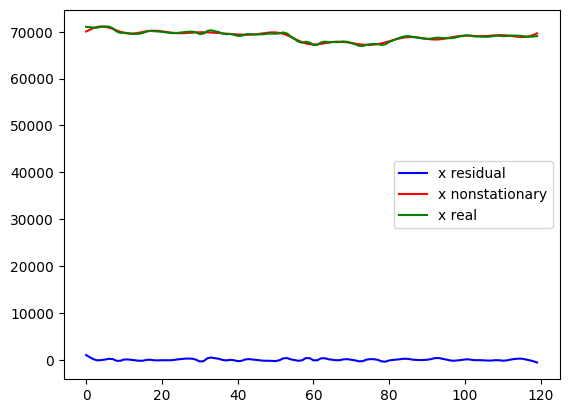

In [ ]:
x_res, x_non = main_freq_part(x, 10)
plt.plot(x_res[0,:,:], color='blue', label='x residual')
plt.plot(x_non[0,:,:], color = 'red', label = 'x nonstationary')
plt.plot(x[0,:,:], color='green', label = 'x real')
plt.legend()
plt.show()

MLPfreq class is a light weight neural network that learn to calculate non sationary part of signal.

In [ ]:
import torch.nn as nn

class MLPfreq(nn.Module):
    def __init__(self, seq_len, pred_len, enc_in):
        super(MLPfreq, self).__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.channels = enc_in

        self.model_freq = nn.Sequential(
            nn.Linear(self.seq_len, 64),
            nn.ReLU(),
        )

        self.model_all = nn.Sequential(
            nn.Linear(64 + seq_len, 128),
            nn.ReLU(),
            nn.Linear(128, pred_len)
        )


    def forward(self, main_freq, x):
        inp = torch.concat([self.model_freq(main_freq), x], dim=-1)
        return self.model_all(inp)

class FAN(nn.Module):
    def __init__(self, seq_len = SEQ_LENGTH, pred_len = SEQ_LENGTH, enc_in = 1, freq_topk=10):
        super(FAN, self).__init__()

        self.seq_len = seq_len
        self.pred_len = pred_len
        self.enc_in = enc_in
        self.freq_topk = freq_topk
        self._build_model()
        self.pred_main_freq_signal = None
        self.pred_residual = None

    def _build_model(self):
        self.model_freq = MLPfreq(seq_len=self.seq_len, pred_len = self.pred_len, enc_in = self.enc_in)

    def loss(self, true):
        residual, pred_main = main_freq_part(true, self.freq_topk)
        lf = nn.functional.mse_loss
        return lf(self.pred_main_freq_signal, pred_main) + lf(self.pred_residual, residual)

    def normalize(self, input):
        x_non, x_res = main_freq_part(input, self.freq_topk)
        self.pred_main_freq_signal = self.model_freq(x_res.transpose(1,2), input.transpose(1,2)).transpose(1,2)
        return x_non.reshape(input.shape[0],input.shape[1],input.shape[2])

    def denormalize(self, x_non):
        self.pred_residual = x_non
        output = self.pred_residual + self.pred_main_freq_signal
        return output.reshape(x_non.shape[0], x_non.shape[1], x_non.shape[2])


    def forward(self, batch_x, mode='n'):
        if mode == 'n':
            return self.normalize(batch_x)
        elif mode == 'd':
            return self.denormalize(batch_x)
        else:
            raise ValueError("Mode must be 'n' or 'd'.")



## xlstm model

In [ ]:
from xlstm import (
    xLSTMBlockStack,
    xLSTMBlockStackConfig,
    mLSTMBlockConfig,
    mLSTMLayerConfig,
    sLSTMBlockConfig,
    sLSTMLayerConfig,
    FeedForwardConfig,
)

def create_xlstm_model(seq_length):
    # Define your input size, hidden size, and other relevant parameters
    input_size = 1  # Number of features in your time series
    embedding_dim = 32  # Dimension of the embeddings, reduced to save memory
    output_size = 1  # Number of output features (predicting the next value)

    # Define the xLSTM configuration
    cfg = xLSTMBlockStackConfig(
        mlstm_block=mLSTMBlockConfig(
            mlstm=mLSTMLayerConfig(
                conv1d_kernel_size=4, qkv_proj_blocksize=2, num_heads=2  # Reduced parameters to save memory
            )
        ),
        slstm_block=sLSTMBlockConfig(
            slstm=sLSTMLayerConfig(
                backend="cuda",
                num_heads=2,  # Reduced number of heads to save memory
                conv1d_kernel_size=2,  # Reduced kernel size to save memory
                bias_init="powerlaw_blockdependent",
            ),
            feedforward=FeedForwardConfig(proj_factor=1.1, act_fn="gelu"),  # Reduced projection factor to save memory
        ),
        context_length=seq_length,
        num_blocks=4,  # Reduced number of blocks to save memory
        embedding_dim=embedding_dim,
        slstm_at=[1],
    )


    # Instantiate the xLSTM stack
    xlstm_stack = xLSTMBlockStack(cfg).to("cuda")


    # Add a linear layer to project input data to the required embedding dimension
    input_projection = nn.Linear(input_size, embedding_dim).to("cuda")


    # Add a final linear layer to project the xLSTM output to the desired output size
    output_projection = nn.Linear(embedding_dim, output_size).to("cuda")


    return xlstm_stack, input_projection, output_projection

## Model Wrapper (FANxLSTMWrapper)

In [ ]:
class FANxLSTMWrapper(nn.Module):
    def __init__(self, fan_layer, input_projection, xlstm_stack, output_projection):
        super().__init__()

        self.fan_layer = fan_layer
        self.input_projection = input_projection
        self.xlstm_stack = xlstm_stack
        self.output_projection = output_projection

    def forward(self,x, y=None):

        #x.shape = 16,120,1
        x_normalized = self.fan_layer(x, mode='n')
        # x_normalized.shape = 16,120,1
        x_projected = self.input_projection(x_normalized)
        # x_projected.shape = 16,120,32
        xlstm_output = self.xlstm_stack(x_projected)
        # xlstm_output.shape = 16,120,32
        predictions = self.output_projection(xlstm_output)
        #prediction.shape = 16,120,1
        x_reconstructed = self.fan_layer(predictions, mode='d')
        # x_reconstructd.shape = 16,120,1

        return predictions, x_reconstructed

## Train loop

In [ ]:
def batch_min_max_scaler(data, min_val=None, max_val=None):
    if min_val is None or max_val is None:
      min_val = data.min()
      max_val = data.max()

    scale = max_val - min_val
    scale[scale == 0] = 1.0 # set scale to 1 when all values are the same

    normalized_data = (data - min_val)/scale
    return normalized_data

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

def train_model(fan_xlstm_wrapper, train_denoised_loader, xs_val_denoised, ys_val):


    val_combine_dataloader = create_dataloader(xs_val_denoised, ys_val)
    # Hyper parameters
    lr = 0.0001
    num_epochs = 200
    batch_size = 16  # Reduced batch size to save memory

    best_val_loss = float('inf')
    patience = 10
    trigger_times = 0

    fan_xlstm_wrapper = fan_xlstm_wrapper.to('cuda')

    criterion_xlstm = nn.MSELoss()
    optimizer = optim.Adam(fan_xlstm_wrapper.parameters(), lr=lr)

    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)  # Learning rate scheduler
    initial_lr = optimizer.param_groups[0]['lr']
    lr_reduced = False # Flag to track if learning rate has been reduced

    SaveInfo = {
        'EpochLoss':np.zeros((num_epochs,1), dtype=np.float32),
        'ValLoss': np.zeros((num_epochs,1), dtype=np.float32),
    }

    for epoch in range(num_epochs):
        fan_xlstm_wrapper.train()

        BatchLoss=[]
        total_loss = 0

        for batch_x, batch_y in train_denoised_loader:
            # forward pass
            batch_x = batch_x.to('cuda').float()
            batch_y = batch_y.to('cuda').float()

            batch_x = batch_min_max_scaler(batch_x)
            batch_y = batch_min_max_scaler(batch_y)

            predictions, reconstructed_output = fan_xlstm_wrapper(batch_x)

            # The article mentions that xlstm loss must be the difference between y and yhat. This is correct.
            xlstm_loss = criterion_xlstm(reconstructed_output[:,-1,:].squeeze(), batch_y.squeeze())

            # The article mentions that fan loss should be the difference between y_non and yhat_not.
            fan_loss = fan_xlstm_wrapper.fan_layer.loss(batch_x)

            # Combined loss
            loss = fan_loss + xlstm_loss

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss +=loss.item()

            BatchLoss.append(loss.item())

        fan_xlstm_wrapper.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_combine_dataloader:
                batch_x = batch_x.to('cuda').float()
                batch_y = batch_y.to('cuda').float()

                batch_x = batch_min_max_scaler(batch_x)
                batch_y = batch_min_max_scaler(batch_y)

                _, reconstructed_output = fan_xlstm_wrapper(batch_x)
                val_loss += criterion_xlstm(reconstructed_output[:,-1,:].squeeze(), batch_y.squeeze()).item()

        val_loss /=len(val_combine_dataloader)

        scheduler.step(val_loss)  # Adjust learning rate based on validation loss

        SaveInfo['ValLoss'][epoch] = val_loss
        SaveInfo['EpochLoss'][epoch] = np.mean(BatchLoss)

        # Print learning rate reduction only once
        if not lr_reduced and optimizer.param_groups[0]['lr'] < initial_lr:
            print(f'Epoch [{epoch + 1}/{num_epochs}], Reducing learning rate to {optimizer.param_groups[0]["lr"]}')
            lr_reduced = True

        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {np.mean(BatchLoss):.8f}, Validation Loss: {val_loss:.8f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(fan_xlstm_wrapper.state_dict(), f'{FILE_NAME}/xlstm_fan_{FREQ}.pth')
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print('Early stopping!')
                break

    print("Training complete!")

    return SaveInfo, fan_xlstm_wrapper

def evaluate_model(fan_xlstm_wrapper, test_x_denoised):

    test_x_denoised = test_x_denoised.to('cuda')

    fan_xlstm_wrapper.load_state_dict(torch.load(f'{FILE_NAME}/xlstm_fan_{FREQ}.pth'))

    fan_xlstm_wrapper.eval()
    test_predictions = []
    with torch.no_grad():
        _, recounstructed_output = fan_xlstm_wrapper(test_x_denoised)

        test_predictions = recounstructed_output[:,-1,:]

    return test_predictions



## Build instances and train model

In [ ]:
from torchsummary import summary

In [ ]:
x, y = next(iter(train_denoised_dataloader))
fan_layer = FAN(seq_len=SEQ_LENGTH, pred_len=1, enc_in = 1, freq_topk=1)


In [ ]:
fan_layer = FAN(seq_len=SEQ_LENGTH, pred_len=120, enc_in = 1, freq_topk=K).to('cuda')

xlstm_stack, input_projection, output_projection = create_xlstm_model(SEQ_LENGTH)

fan_xlstm_wrapper = FANxLSTMWrapper(fan_layer, input_projection, xlstm_stack, output_projection).cuda()

# summary(fan_xlstm_wrapper, (BATCH_SIZE, SEQ_LENGTH, 1))

In [ ]:
SaveInfo, fan_xlstm_wrapper = train_model(fan_xlstm_wrapper, train_denoised_dataloader, xs_val_denoised, ys_val)

Epoch [1/200], Loss: 0.31742267, Validation Loss: 0.09720716
Epoch [2/200], Loss: 0.11652821, Validation Loss: 0.08438491
Epoch [3/200], Loss: 0.10218905, Validation Loss: 0.07979278
Epoch [4/200], Loss: 0.09724001, Validation Loss: 0.07708168
Epoch [5/200], Loss: 0.09403248, Validation Loss: 0.07524149
Epoch [6/200], Loss: 0.09180138, Validation Loss: 0.07381323
Epoch [7/200], Loss: 0.09010297, Validation Loss: 0.07269941
Epoch [8/200], Loss: 0.08881109, Validation Loss: 0.07160381
Epoch [9/200], Loss: 0.08764505, Validation Loss: 0.07080230
Epoch [10/200], Loss: 0.08668800, Validation Loss: 0.07013512
Epoch [11/200], Loss: 0.08592757, Validation Loss: 0.06967793
Epoch [12/200], Loss: 0.08520564, Validation Loss: 0.06911226
Epoch [13/200], Loss: 0.08464918, Validation Loss: 0.06884614
Epoch [14/200], Loss: 0.08412644, Validation Loss: 0.06840069
Epoch [15/200], Loss: 0.08362208, Validation Loss: 0.06829348
Epoch [16/200], Loss: 0.08318762, Validation Loss: 0.06776377
Epoch [17/200], L

In [ ]:
test_predictions = evaluate_model(fan_xlstm_wrapper, xs_test_denoised)

In [ ]:
os.getcwd()
torch.save(test_predictions, f'{FILE_NAME}/test_predictions.pt')

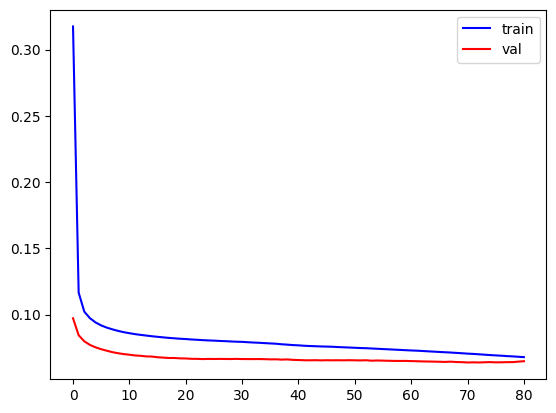

In [ ]:
train_loss = SaveInfo.get('EpochLoss')
ind = np.where(SaveInfo.get('EpochLoss') == 0)[0][0]
plt.plot(train_loss[:ind], label='train', color='blue')
ValLoss = SaveInfo.get('ValLoss')
plt.plot(ValLoss[:ind], label='val', color='red')
plt.legend()
plt.show()

## Calculate accuracy

In [ ]:
train_predictions = evaluate_model(fan_xlstm_wrapper, xs_train_denoised)
val_predictions = evaluate_model(fan_xlstm_wrapper, xs_val_denoised)

torch.save(train_predictions, f'{FILE_NAME}/train_predictions.pt')
torch.save(val_predictions, f'{FILE_NAME}/val_predictions.pt')


fan_xlstm (float32) | Train Accuracy: 53.23%
fan_xlstm (float32) | Validation Accuracy: 51.76%
fan_xlstm (float32) | Test Accuracy: 51.83%
fan_xlstm (float32) | Recall: 57.12%
fan_xlstm (float32) | Precision (Rise): 54.02%
fan_xlstm (float32) | Precision (Fall): 49.07%
fan_xlstm (float32) | F1 Score: 55.53%


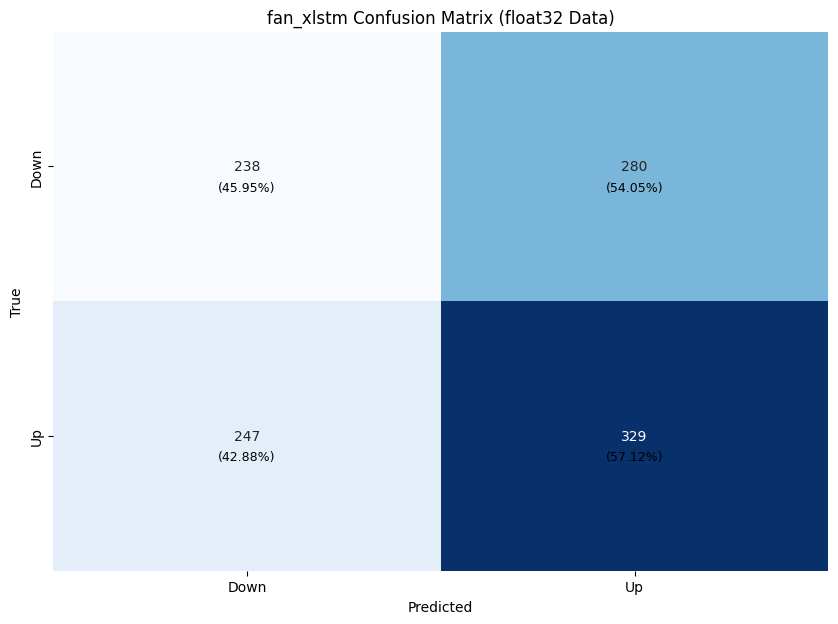

In [ ]:
from direction_prediction.directional_prediction import evaluate_directional_movement
true_labels, predicted_labels, metrics_direction = evaluate_directional_movement(train_denoised[120:], train_predictions.cpu().numpy(), val_denoised[120:], val_predictions.cpu().numpy(), test_denoised[120:], test_predictions.cpu().numpy(), model_name='fan_xlstm', data_type='float32', using_darts=False)

In [ ]:
!pip insatall darts

NotImplementedError: A UTF-8 locale is required. Got ANSI_X3.4-1968

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score
from darts import TimeSeries
import numpy as np

# -------------------------------------------------------------------------------------------
# Forecasting metrics
#
# https://gist.github.com/bshishov/5dc237f59f019b26145648e2124ca1c9
# -------------------------------------------------------------------------------------------

def _naive_forecasting(actual: np.ndarray, seasonality: int = 1):
    # Naive forecasting method which just repeats previous samples
    return actual[:-seasonality]

def root_mean_squared_scaled_error(actual: np.ndarray, predicted: np.ndarray, seasonality: int = 1):
    # RMSSE - Root Mean Squared Scaled Error
    q = mean_squared_error(actual, predicted) / mean_squared_error(actual[seasonality:], _naive_forecasting(actual, seasonality))
    return np.sqrt(q)

def mean_absolute_scaled_error(actual: np.ndarray, predicted: np.ndarray, seasonality: int = 1):
    # MASE - Mean Absolute Scaled Error
    return mean_absolute_error(actual, predicted) / mean_absolute_error(actual[seasonality:], _naive_forecasting(actual, seasonality))

def calculate_metrics(actual, prediction, model_name, data_type):
    # Convert Darts TimeSeries to NumPy arrays if necessary
    if isinstance(actual, TimeSeries):
        actual = actual.values().flatten()
    if isinstance(prediction, TimeSeries):
        prediction = prediction.values().flatten()

    # Calculate metrics using scikit-learn functions
    metrics = {
        "MAE": mean_absolute_error(actual, prediction),
        "MSE": mean_squared_error(actual, prediction),
        "RMSE": root_mean_squared_error(actual, prediction),
        "RMSSE": root_mean_squared_scaled_error(actual, prediction),
        "MAPE": mean_absolute_percentage_error(actual, prediction) * 100,
        "MASE": mean_absolute_scaled_error(actual, prediction),
        "R2": r2_score(actual, prediction)
    }

    for metric_name, metric_value in metrics.items():
        value_str = f"{metric_value:.2f}"
        if metric_name == "MAPE":
            value_str += "%"
        print(f"{model_name} ({data_type}) | {metric_name}: {value_str}")

    return metrics

In [ ]:
model_name = 'xLSTM_fan'
data_type = 'float32'

plt.plot(xs_test[-20:].cpu(), label='test_y', color='blue')
plt.plot(test_predictions.cpu()[-20:], label='test_predictions', color='red')
plt.legend()
plt.show()

In [ ]:
metrics_price = calculate_metrics(test_denoised[120:], test_predictions, model_name, data_type)